# Imports

In [1]:
!cd ../ && bash env.sh 

bash: env.sh: No such file or directory


In [2]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys 
import scanpy as sc
import warnings
import scanpy as sc
import anndata as ad
import os
from scipy.sparse import issparse
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
plt.rcParams["font.family"] = "Arial"
main_dir = '../'
# task_grn_inference_dir = '../../'
output_dir = f"{main_dir}/output/"

# - local imports 
from hiara import retrieve_feature_data, retrieve_sig_stats

from hiara import SUB_CT_LABEL, DATA_DIR, FEATURES_DIR, PRIOR_DIR, PLOTS_DIR, CLOCKS_DIR,  MAJOR_CTS, surrogate_names, colors_blind, palette_major_cts, palette_datasets, palette_datasets_pretty, palette_genders, AGING_COHORTS
from hiara import retrieve_adata, retrieve_net, retrieve_net_consensus, retrieve_stats
from geneRNBI.src.exp_analysis.helper import plot_interactions, create_interaction_df

from geneRNBI.src.helper import load_env
env = load_env()
TASK_GRN_INFERENCE_DIR = env['TASK_GRN_INFERENCE_DIR']

In [3]:
adata = retrieve_adata(dataset='aida')
adata.obs.groupby('Major_CT')['donor_age'].nunique()

Major_CT
B       615
CD4T    622
CD8T    621
MONO    622
NK      619
Name: donor_age, dtype: int64

# Sub CT distribution

In [14]:
obs = retrieve_adata(dataset='op', data_type='sc', only_obs=True)
obs.groupby(['condition', 'Sub_CT']).size()

condition                                                             Sub_CT          
5-(9-Isopropyl-8-methyl-2-morpholino-9H-purin-6-yl)pyrimidin-2-amine  Tcm_Naive_CD4       453
                                                                      Tem_Effector_CD4    298
                                                                      Tcm_Naive_CD8        68
                                                                      Tem_Trm_CD8          98
                                                                      Tem_Temra_CD8       118
                                                                                         ... 
YK 4-279                                                              CD16_NK             132
                                                                      Classic_MONO         32
                                                                      NonClassic_MONO       0
                                                                   

In [ ]:
from hiara import SUB_CTS, DISCOVERY_COHORTS
samples_n_store = []
for d in DISCOVERY_COHORTS:
    obs = retrieve_adata(dataset=d, data_type='sc', only_obs=True)
    samples = obs['Sub_CT'].value_counts()
    samples_n = samples/samples.max()
    samples_n = samples_n.reset_index()
    samples_n.columns = ['Sub_CT', 'ratio']
    samples_n['dataset'] = d
    samples_n_store.append(samples_n)

In [21]:
samples_n_mean = pd.concat(samples_n_store).groupby(['Sub_CT']).agg({'ratio': ['mean']})
print('Sub types passed the sample size filter:')
samples_n_mean[samples_n_mean>0.5].dropna().index.tolist()

Sub types passed the sample size filter:


['CD16_NK',
 'Classic_MONO',
 'MAIT',
 'Memory_B',
 'Naive_B',
 'NonClassic_MONO',
 'Tcm_Naive_CD4',
 'Tcm_Naive_CD8',
 'Tem_Effector_CD4',
 'Tem_Temra_CD8',
 'Tem_Trm_CD8']

# Discovery vs validation: TF analysis

In [36]:
cell_type = 'CD8T'
stats_ref = retrieve_sig_stats()[['gene', 'slope', 'meta_p_adj', 'cell_type']]
stats_ref = stats_ref.groupby(['cell_type','gene']).agg({'slope': 'mean', 'meta_p_adj': 'min'}).reset_index()
stats_val = retrieve_stats(data_type='bulk', feature_type='tf_activity', dataset='soundlife', multi_cohort=False).drop_duplicates(subset={'cell_type', 'gene'})[['gene', 'slope', 'p_value_adj', 'cell_type']]

# Ensure cell_type columns are strings before renaming
stats_ref['cell_type'] = stats_ref['cell_type'].astype(str)
stats_val['cell_type'] = stats_val['cell_type'].astype(str)

stats_ref.columns = ['Cell type', 'TF', 'Slope (discovery)', 'Meta-p adj (discovery)']
stats_val.columns = ['TF', 'Slope (validation)', 'P adj (validation)', 'Cell type']
stats_merged = stats_ref.merge(stats_val, on=['Cell type', 'TF'], suffixes=('_ref', '_val'), how='left')
# only in ref
missed_ones = stats_merged[(stats_merged['P adj (validation)']>0.05) & (stats_merged['Slope (validation)']<0.1)]
file_name = f'{FEATURES_DIR}/missing_tfs_validation.csv'
print(f'Saving to {file_name}')
missed_ones.to_csv(file_name, index=False)
missed_ones.sort_values('Meta-p adj (discovery)', ascending=False)

Saving to /Users/jno24/Documents/projs/ongoing/hiara/base_folder/output//features//missing_tfs_validation.csv


,Cell type,TF,Slope (discovery),Meta-p adj (discovery),Slope (validation),P adj (validation)
527,MONO,GATAD2B,-0.151293,1.534065e-07,-0.010862,0.817225
85,CD4T,SLC2A4RG,0.174569,1.154589e-09,0.012926,0.776654
500,MONO,AKNA,-0.204926,9.764735e-11,-0.013732,0.766713
36,CD4T,HMG20B,0.212808,1.057397e-13,0.055512,0.174835
507,MONO,BAZ2B,-0.215703,7.201749e-14,-0.022699,0.618652
...,...,...,...,...,...,...
424,CD8T,ZNF296,0.491203,1.373679e-55,0.054373,0.117879
138,CD8T,ARHGAP35,0.509712,2.049396e-56,-0.004915,0.895397
370,CD8T,XPA,-0.458822,9.833727e-57,-0.028868,0.412836
359,CD8T,THRA,-0.493521,3.069309e-58,-0.002888,0.938809


In [42]:
stats_val_sig = stats_val[stats_val['P adj (validation)']<=0.05]
stats_merged = stats_ref.merge(stats_val_sig, on=['TF', 'Cell type'], suffixes=('_ref', '_val'), how='left')
# find genes with inconsistent slopes
stats_inconsistent = stats_merged[(stats_merged['Slope (discovery)'] * stats_merged['Slope (validation)'] < 0)]
file_name = f'{FEATURES_DIR}/inconsistent_tfs_validation.csv'
print(f'Saving to {file_name}')
stats_inconsistent.to_csv(file_name, index=False)
stats_inconsistent

Saving to /Users/jno24/Documents/projs/ongoing/hiara/base_folder/output//features//inconsistent_tfs_validation.csv


,Cell type,TF,Slope (discovery),Meta-p adj (discovery),Slope (validation),P adj (validation)
0,B,ATF7,0.170458,1.725928e-10,-0.157677,6.926414e-06
1,B,ZFP91,0.142219,1.778482e-08,-0.195083,5.949041e-08
2,B,ZNF740,0.176291,1.203542e-08,-0.167523,2.132770e-06
90,CD4T,SNAPC5,0.169037,1.377922e-12,-0.086085,2.234270e-02
133,CD8T,AEBP2,0.383563,5.704385e-42,-0.138773,5.399928e-05
...,...,...,...,...,...,...
436,CD8T,ZNF410,0.460694,8.163338e-49,-0.178784,1.731621e-07
445,CD8T,ZNF487,0.478853,1.699075e-51,-0.115919,7.789741e-04
469,CD8T,ZNF655,0.483825,7.555242e-52,-0.071854,3.788672e-02
488,CD8T,ZNF808,0.484939,1.034954e-53,-0.222425,6.253531e-11


# OPSCA

In [27]:
adata = retrieve_adata(dataset='CXCL9', cell_type='CD4T')

In [11]:
adata_sub = adata[adata.obs['condition'].isin(['Ruxolitinib'])]
adata_sub.obs.groupby('cell_type')['condition'].value_counts()

cell_type  condition  
B          Ruxolitinib    205
CD4T       Ruxolitinib    611
CD8T       Ruxolitinib    331
MONO       Ruxolitinib     49
NK         Ruxolitinib    109
Name: count, dtype: int64

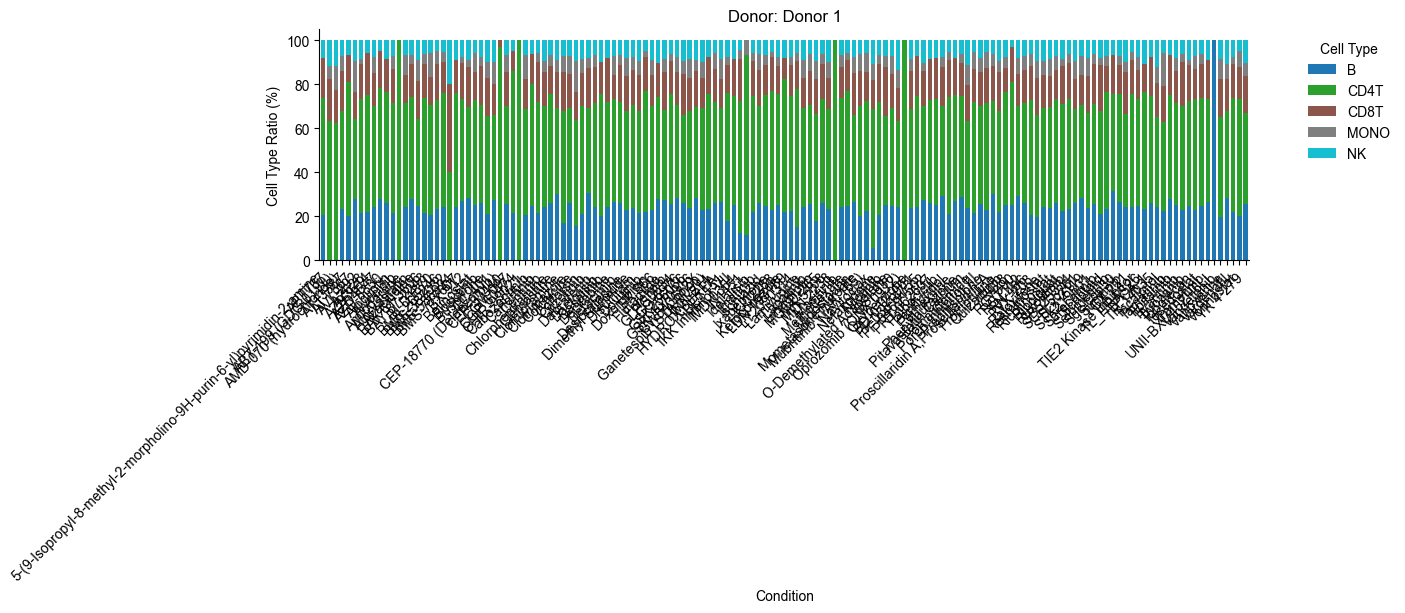

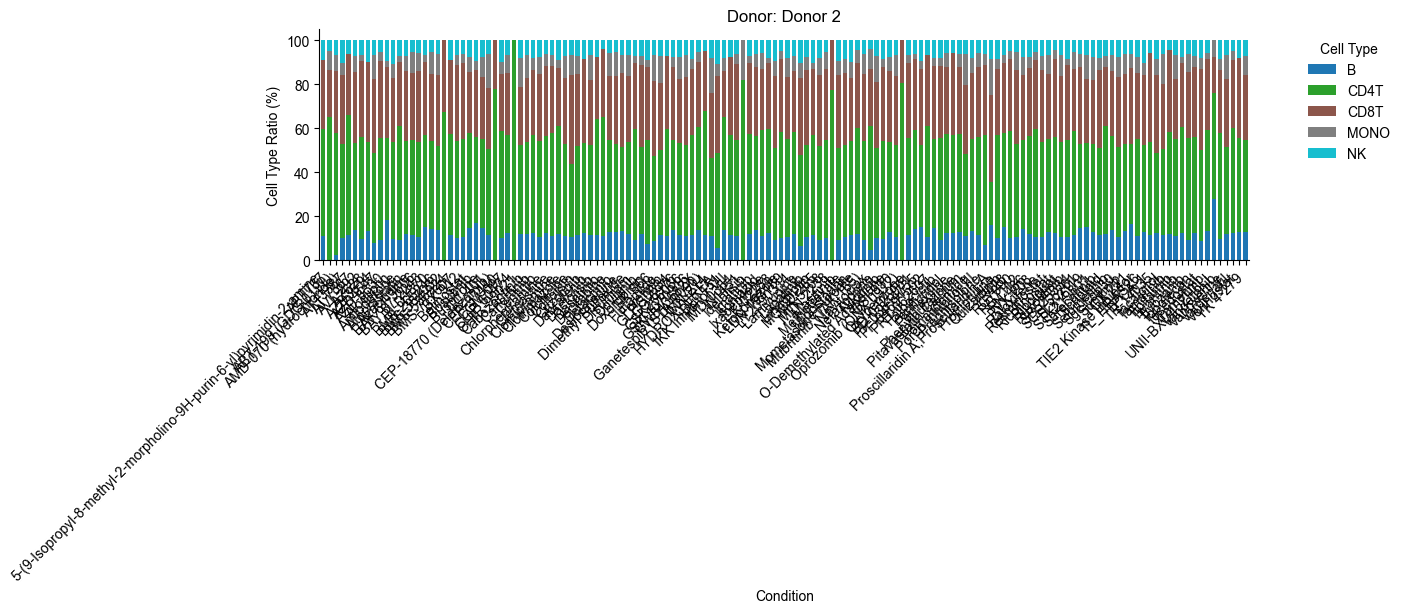

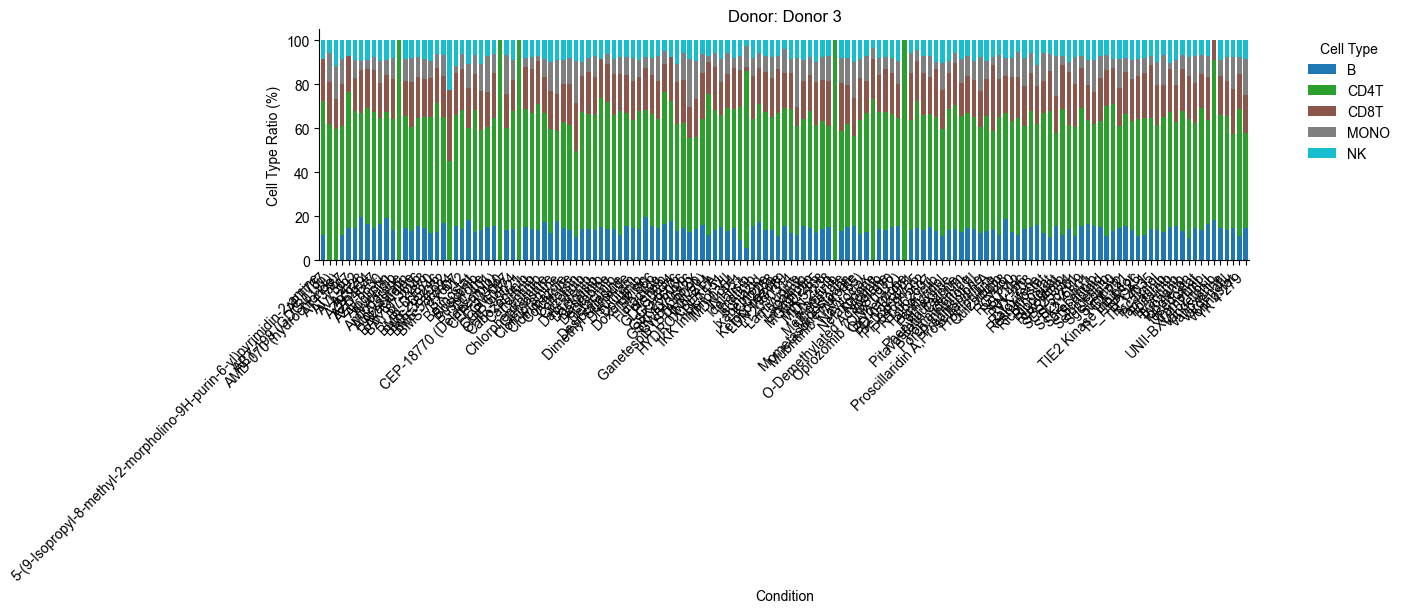

In [8]:
adata = ad.read_h5ad(f'{DATA_DIR}/sc/op.h5ad', backed='r')
for donor in adata.obs['donor_id'].unique():
    adata_donor = adata[adata.obs['donor_id'] == donor]
    
    # Count cells by condition and cell type
    counts = adata_donor.obs.groupby(['condition', 'cell_type']).size().reset_index(name='count')
    
    # Pivot for stacked bar plot
    counts_pivot = counts.pivot(index='condition', columns='cell_type', values='count').fillna(0)
    
    # Calculate percentages
    counts_pct = counts_pivot.div(counts_pivot.sum(axis=1), axis=0) * 100
    
    # Plot stacked bar plot
    fig, ax = plt.subplots(figsize=(20, 3))
    counts_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', width=0.7)
    
    ax.set_xlabel('Condition')
    ax.set_ylabel('Cell Type Ratio (%)')
    ax.set_title(f'Donor: {donor}', fontweight='bold')
    ax.legend(title='Cell Type', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

In [153]:
condition = ['DMSO'] #, '24 h LPS', '24 h LPS + ruxolitinib'
# condition = None
dataset = 'op'
cell_type = 'CD4T'
adata = retrieve_adata(data_type='sc', condition=condition, dataset=dataset, cell_type=cell_type)

In [157]:
adata.obs.groupby(['plate_name', 'condition', 'well']).size()

plate_name       condition  well
NeurIPS2023-010  DMSO       A3      248
                            B3      245
                            C3      245
                            D3      264
                            E3      220
                            F3      314
                            G3      197
                            H3      256
NeurIPS2023-011  DMSO       A3      290
                            B3      176
                            C3      267
                            D3      208
                            E3      158
                            F3      192
                            G3      232
                            H3      284
NeurIPS2023-012  DMSO       A3      284
                            B3      399
                            C3      196
                            D3      230
                            E3      209
                            F3      127
                            G3      246
                            H3      214
NeurIPS

In [150]:
from hiara import get_config
from task_grn_inference.src.process_data.helper_data import bulkify_func
def normalize(adata):
    sc.pp.normalize_total(adata, target_sum=1e6)
    sc.pp.log1p(adata)
    return adata

cfg = get_config(dataset)
pseudobulk_group = cfg.pseudobulk_group

# - main bulk data (per major celltype)
print('Bulkifying main cell types')

# adata_sub.X = adata_sub.layers['counts']
adata_bulk_major_celltypes = bulkify_func(adata, covariates=pseudobulk_group)
adata_bulk_major_celltypes = normalize(adata_bulk_major_celltypes)
low_cells = adata_bulk_major_celltypes.obs['cell_count'] < 10
print(f'Dropping {low_cells.sum()} bulk samples with less than 10 cells')
adata_bulk_major_celltypes = adata_bulk_major_celltypes[~low_cells].copy()
print(adata_bulk_major_celltypes.shape)
# adata_bulk_major_celltypes.write()
adata_bulk_major_celltypes.write(f'{DATA_DIR}/bulk/{dataset}.h5ad')

Bulkifying main cell types
Dropping 0 bulk samples with less than 10 cells
(439, 13321)
Dropping 0 bulk samples with less than 10 cells
(439, 13321)


# CXCL9

In [159]:
condition = ['24 h RPMI', '24 h RPMI + ruxolitinib', '24 h LPS', '24 h LPS + ruxolitinib'] #, '24 h LPS', '24 h LPS + ruxolitinib'
dataset = 'CXCL9'
cell_type = 'CD4T'
adata = retrieve_adata(data_type='sc', condition=condition, dataset=dataset, cell_type=cell_type)
adata.X = adata.layers['counts'] 
# adata.layers['counts'].max()

In [113]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [114]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat_v3')
sc.pp.pca(adata, n_comps=50, use_highly_variable=True)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5)

In [126]:
adata_sub.obs

,dataset,donor_id,age,sex,batch_info,pool_id,donor_letter,treatment_id,condition,donor_age,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,n_genes,Major_CT,Sub_CT,cell_type,leiden
pool-AG1_AAACCGCTCCTGTCTG-1,CXCL9,CXCL9_TI_D,25,Female,CXCL9_TI_AG1,AG1,D,4,24 h RPMI + ruxolitinib,CXCL9_TI_D25,1737,3210.0,45.0,1.401869,1737,CD4T,Tcm_Naive_CD4,CD4T,4
pool-AG1_AAATTCGCAATACAGC-1,CXCL9,CXCL9_TI_B,28,Female,CXCL9_TI_AG1,AG1,B,2,24 h RPMI,CXCL9_TI_B28,598,907.0,49.0,5.402426,598,CD4T,Tcm_Naive_CD4,CD4T,4
pool-AG1_AACACACCAGCACGTA-1,CXCL9,CXCL9_TI_D,25,Female,CXCL9_TI_AG1,AG1,D,4,24 h RPMI + ruxolitinib,CXCL9_TI_D25,1372,2382.0,34.0,1.427372,1372,CD4T,Tcm_Naive_CD4,CD4T,4
pool-AG1_AACCAGCTCCCCAAGG-1,CXCL9,CXCL9_TI_B,28,Female,CXCL9_TI_AG1,AG1,B,2,24 h RPMI,CXCL9_TI_B28,683,1143.0,68.0,5.949256,683,CD4T,Tcm_Naive_CD4,CD4T,4
pool-AG1_AACGAATGTAAGCCAA-1,CXCL9,CXCL9_TI_D,25,Female,CXCL9_TI_AG1,AG1,D,4,24 h RPMI + ruxolitinib,CXCL9_TI_D25,370,562.0,40.0,7.117437,370,CD4T,Tcm_Naive_CD4,CD4T,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pool-AG7_TGTAAGGGTTGTGGCC-1,CXCL9,CXCL9_TI_C,31,Male,CXCL9_TI_AG7,AG7,C,4,24 h RPMI + ruxolitinib,CXCL9_TI_C31,1289,2155.0,67.0,3.109049,1289,CD4T,Tcm_Naive_CD4,CD4T,4
pool-AG7_TGTAGCATCACAGCCG-1,CXCL9,CXCL9_TI_C,31,Male,CXCL9_TI_AG7,AG7,C,4,24 h RPMI + ruxolitinib,CXCL9_TI_C31,1028,1569.0,57.0,3.632887,1028,CD4T,Tcm_Naive_CD4,CD4T,4
pool-AG7_TGTATAGCAACCCGAA-1,CXCL9,CXCL9_TI_A,29,Male,CXCL9_TI_AG7,AG7,A,2,24 h RPMI,CXCL9_TI_A29,810,1216.0,10.0,0.822368,810,CD4T,Tcm_Naive_CD4,CD4T,4
pool-AG7_TGTCCAGGTTAGCATC-1,CXCL9,CXCL9_TI_C,31,Male,CXCL9_TI_AG7,AG7,C,4,24 h RPMI + ruxolitinib,CXCL9_TI_C31,1552,2935.0,55.0,1.873935,1552,CD4T,Tcm_Naive_CD4,CD4T,4


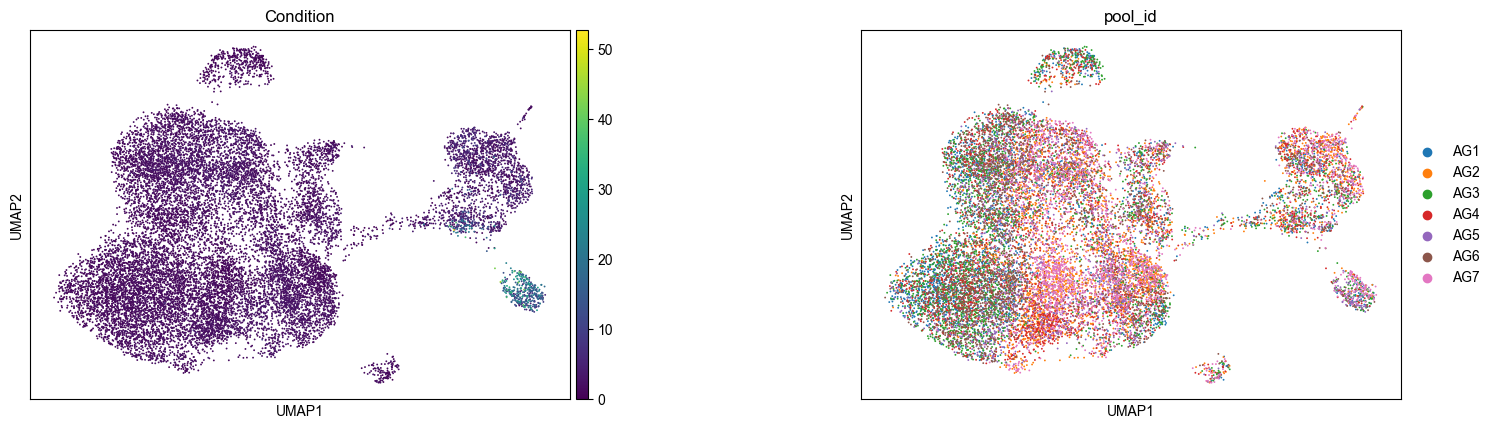

condition
24 h RPMI                  7831
24 h RPMI + ruxolitinib    9083
dtype: int64

In [135]:
# adata_sub = adata[~adata.obs['leiden'].isin(['9', '4', '10'])] #'4', 
# adata_sub = adata[adata.obs['leiden'].isin(['4'])] #'4', 
adata_sub = adata.copy()
# sc.pl.pca(adata_sub, color=['donor_id'], show=True, title='Condition', wspace=0.4)
sc.pl.umap(adata_sub, color=['pct_counts_mt', 'pool_id'], show=True, title='Condition', wspace=0.4)
# sc.pl.pca(adata_sub, color=['condition'], show=True, title='Condition', wspace=0.4)
# sc.pl.pca(adata_sub, color='leiden', show=True, title='Leiden Clusters', legend_fontsize=8)
adata_sub.obs.groupby(['condition']).size().sort_values()

In [160]:
from hiara import get_config
from task_grn_inference.src.process_data.helper_data import bulkify_func
def normalize(adata):
    sc.pp.normalize_total(adata, target_sum=1e6)
    sc.pp.log1p(adata)
    return adata

cfg = get_config(dataset)
pseudobulk_group = cfg.pseudobulk_group

# - main bulk data (per major celltype)
print('Bulkifying main cell types')
adata_sub = adata.copy()
# adata_sub.X = adata_sub.layers['counts']
adata_bulk_major_celltypes = bulkify_func(adata_sub, covariates=pseudobulk_group)
adata_bulk_major_celltypes = normalize(adata_bulk_major_celltypes)
low_cells = adata_bulk_major_celltypes.obs['cell_count'] < 10
print(f'Dropping {low_cells.sum()} bulk samples with less than 10 cells')
adata_bulk_major_celltypes = adata_bulk_major_celltypes[~low_cells].copy()
print(adata_bulk_major_celltypes.shape)
# adata_bulk_major_celltypes.write()
adata_bulk_major_celltypes.write(f'{DATA_DIR}/bulk/CXCL9.h5ad')

Bulkifying main cell types
Dropping 0 bulk samples with less than 10 cells
(28, 15688)
Dropping 0 bulk samples with less than 10 cells
(28, 15688)


In [161]:
adata_bulk_major_celltypes.obs.groupby(['condition']).size()

condition
24 h LPS                   7
24 h LPS + ruxolitinib     7
24 h RPMI                  7
24 h RPMI + ruxolitinib    7
dtype: int64

In [117]:
aaa

NameError: name 'aaa' is not defined

# TF activity trend vs expression trend in aging

In [ ]:
from hiara.src.feature_association.plots import plot_activation_vs_expression

cell_type = 'CD8T'
os.makedirs(PLOTS_DIR, exist_ok=True)
stats_tfs = retrieve_sig_stats()
stats_targets = retrieve_sig_stats(feature_type='gene_expression')
stats_all = stats_tfs[['cell_type', 'tf', 'slope', 'p_value_adj', 'dataset']].merge(
    stats_targets[['cell_type', 'target', 'slope', 'p_value_adj', 'dataset']],
    left_on=['cell_type', 'tf', 'dataset'],
    right_on=['cell_type', 'target', 'dataset'],
    how='inner',
    suffixes=('_source', '_target')
)
stats_all = stats_all[stats_all['dataset'].isin(['data1'])]
stats_all['Activation significance'] = np.sign(stats_all['slope_source']) * -np.log10(stats_all['p_value_adj_source'].clip(lower=1e-300))
stats_all['Expression significance'] = np.sign(stats_all['slope_target']) * -np.log10(stats_all['p_value_adj_target'].clip(lower=1e-300))
df = stats_all[stats_all['cell_type'] == cell_type].copy()
plot_activation_vs_expression(df, col_x = 'Expression significance', 
                                  col_y = 'Activation significance', 
                                  y_label='Activation significance \n (-log10padj)', 
                                  x_label='Expression significance \n (-log10padj)', figsize=(3, 2.7))
plt.legend([],[], frameon=False)                               
plt.suptitle(f"TF activation vs expression ({cell_type})", y=.95, fontsize=12, weight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/activation_vs_expression.png', dpi=300)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/jno24/Documents/projs/ongoing/hiara/base_folder/output//features//gene_expression/stats/stats_multi_cohort_bulk.csv'

# Trajectory plot: TF acitvity with age


In [ ]:

from hiara.src.feature_association.plots import plot_trends
from hiara.src.config import palette_datasets, datasets_e
if True:
    datasets = datasets_e
    # # - load data
    if True:
        cell_type = 'CD8T'
        adata_complete = {dataset: retrieve_adata(dataset) for dataset in datasets}
        adata_dict = {dataset: adata[adata.obs['cell_type'] == cell_type] for dataset, adata in adata_complete.items()}
        nets_dict = {dataset: retrieve_net(dataset, cell_type) for dataset in datasets}
        tf_acts_dict = {}
        for dataset in datasets:
            tf_acts = calculate_tf_activity(adata_dict[dataset], nets_dict[dataset])
            print(tf_acts.shape)
            tf_acts_dict[surrogate_names[dataset]] = tf_acts

    cell_type = 'CD8T'
    genes = ['KLF6']
    
    plot_trends(top_tfs=genes, datasets=[surrogate_names[d] for d in datasets], data_dict=tf_acts_dict, palette=palette_datasets_pretty, cell_type=cell_type, surrogate_names=surrogate_names)
    plt.yticks([])
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/tf_activity/trends_{cell_type}_case.png', dpi=300)

# Compare bulk vs sc GRNs

In [ ]:
if True:
    net_store = []
    for data_type in ['sc', 'bulk']:
        for cell_type in MAJOR_CTS:
            for dataset in DISCOVERY_COHORTS:
                net = retrieve_net(dataset, cell_type, data_type=data_type)
                net['edge'] = net['source'] + '_' + net['target']
                net['cell_type'] = cell_type
                net['dataset'] = dataset
                net['data_type'] = data_type
                net_store.append(net)
    nets_all = pd.concat(net_store)


TFs in sc vs bulk: 203 424
TFs in sc vs bulk: 177 337
TFs in sc vs bulk: 99 468
TFs in sc vs bulk: 304 442
TFs in sc vs bulk: 344 682


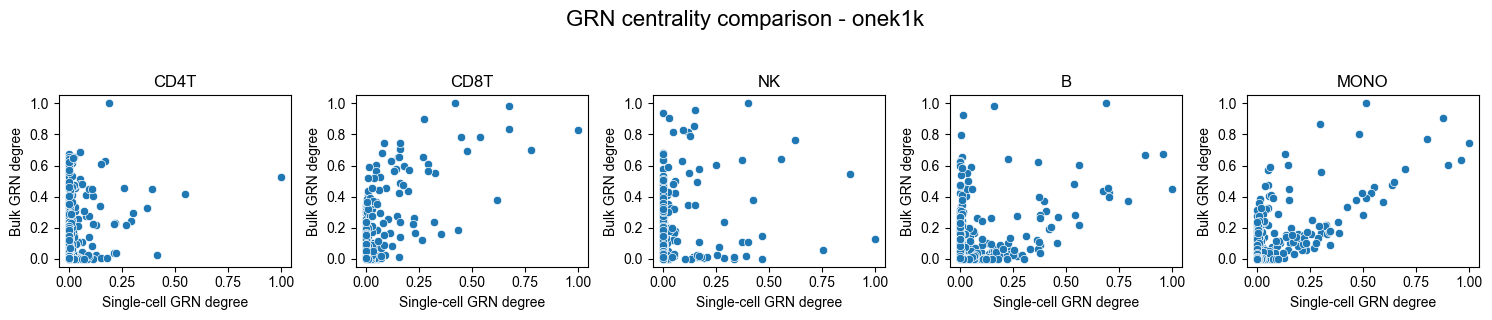

TFs in sc vs bulk: 363 424
TFs in sc vs bulk: 396 399
TFs in sc vs bulk: 270 394
TFs in sc vs bulk: 409 387
TFs in sc vs bulk: 425 322


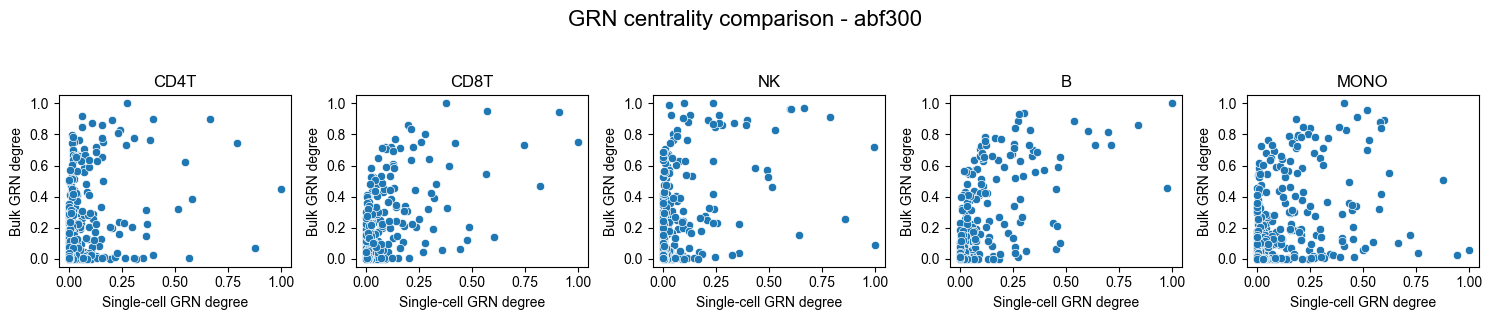

TFs in sc vs bulk: 434 445
TFs in sc vs bulk: 483 481
TFs in sc vs bulk: 392 392
TFs in sc vs bulk: 520 422
TFs in sc vs bulk: 510 449


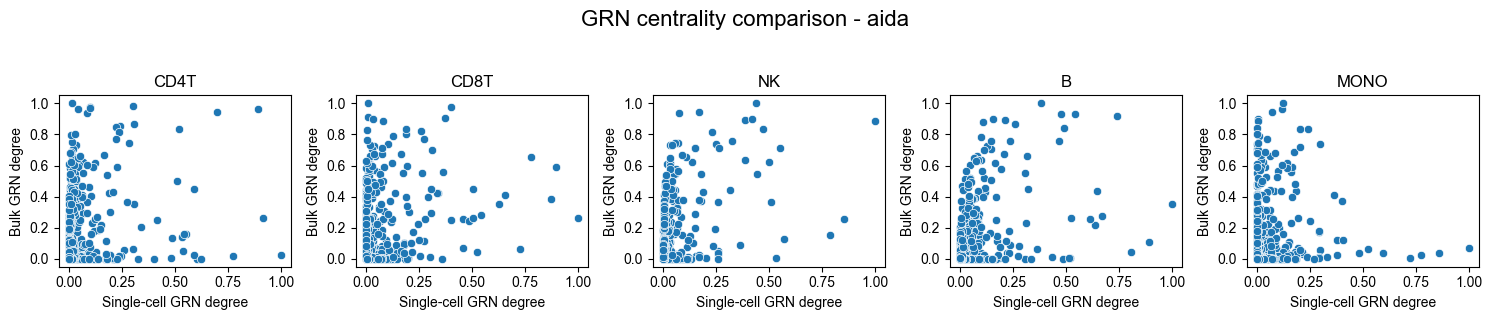

TFs in sc vs bulk: 289 437
TFs in sc vs bulk: 213 438
TFs in sc vs bulk: 186 485
TFs in sc vs bulk: 250 477
TFs in sc vs bulk: 272 481


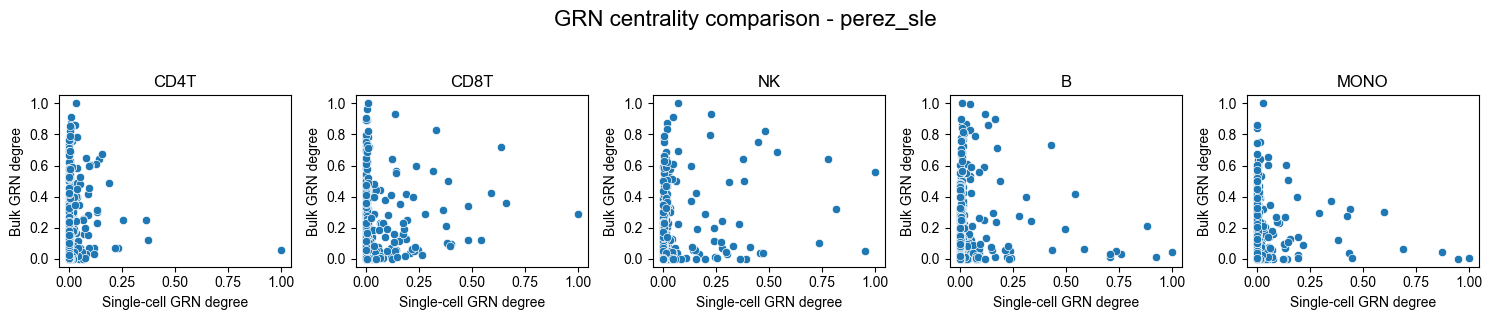

In [ ]:
# - compare centrality
for dataset in nets_all['dataset'].unique():
    fig, axes = plt.subplots(1, len(nets_all['cell_type'].unique()), figsize=(3*len(nets_all['cell_type'].unique()),3))
    for i, cell_type in enumerate(nets_all['cell_type'].unique()):
        net_sc = nets_all[(nets_all['data_type']=='sc') & (nets_all['dataset']==dataset) & (nets_all['cell_type']==cell_type)]
        net_bulk = nets_all[(nets_all['data_type']=='bulk') & (nets_all['dataset']==dataset) & (nets_all['cell_type']==cell_type)]

        # print('TFs in sc vs bulk:', net_sc['source'].nunique(), net_bulk['source'].nunique())
        c_sc = net_sc.groupby('source').size()
        c_bulk = net_bulk.groupby('source').size()

        c_sc = c_sc/c_sc.max()
        c_bulk = c_bulk/c_bulk.max()

        c_sc = c_sc.reset_index().rename(columns={0:'degree_sc'})
        c_bulk = c_bulk.reset_index().rename(columns={0:'degree_bulk'})
        c_all = c_sc.merge(c_bulk, on='source', how='outer').fillna(0)
        
        sns.scatterplot(data=c_all, x='degree_sc', y='degree_bulk', ax=axes[i])
        # plt.xscale('log')
        # plt.yscale('log')
        axes[i].set_xlabel('Single-cell GRN degree')
        axes[i].set_ylabel('Bulk GRN degree')
        axes[i].set_title(f'{cell_type}')
    plt.suptitle(f'GRN centrality comparison - {dataset}', y=1.05, fontsize=16)
    plt.tight_layout()
    plt.show()
    

# Promotor-based GRNs

In [ ]:
# Run full GRN analysis
!cd ../ && python src/feature_association/script.py

# Run promotor-only GRN analysis
!cd ../ && python src/feature_association/script.py --promotor-only

{'type': 'bulk', 'feature_type': 'tf_activity', 'cell_types': ['CD4T', 'CD8T', 'NK', 'B', 'MONO'], 'datasets': ['data1', 'data7_allTPs_jalil', 'data12', 'SLE_European', 'data13_Korean', 'data13_Japanese'], 'association_type': 'spearman', 'cell_type_resolution': 'Major_CT', 'stats_features': '/Users/jno24/Documents/projs/ongoing/hiara/base_folder/output//tf_activity/stats_features_bulk.csv', 'stats_all': '/Users/jno24/Documents/projs/ongoing/hiara/base_folder/output//tf_activity/stats_all_bulk.csv', 'temp_dir': '/Users/jno24/Documents/projs/ongoing/hiara/base_folder/output//tmp/', 'only_promotor_based': False, 'gene_coverage': None}
Calculating TF activity...
Loading data...
Calculating TF activity...
  - Promotor-based only: False
data1 bulk
cell types:   0%|                                         | 0/5 [00:00<?, ?it/s]... storing 'dataset' as categorical
... storing 'condition' as categorical
cell types:  20%|██████▌                          | 1/5 [00:07<00:29,  7.26s/it]... storing 

In [ ]:
# Compare promotor-only vs full GRN results
!cd ../ && python src/experiments/compare_promotor_vs_full.py

PROMOTOR-BASED GRN COMPARISON ANALYSIS

Loading statistics...
  - Full GRN stats: 6356 rows
  - Promotor-only stats: 3281 rows

Running comparisons...

  Cell type: CD4T
    Full GRN: 75 significant TFs
    Promotor-only: 30 significant TFs
    Overlap: 30 TFs (40.0%)
    Jaccard index: 0.400
Saved Venn diagram to /Users/jno24/Documents/projs/ongoing/hiara/base_folder/output//plots//promotor_comparison/venn_CD4T.png
Saved correlation plot to /Users/jno24/Documents/projs/ongoing/hiara/base_folder/output//plots//promotor_comparison/correlation_CD4T.png
    Effect size correlation (Spearman): ρ=0.951

  Cell type: CD8T
    Full GRN: 227 significant TFs
    Promotor-only: 114 significant TFs
    Overlap: 114 TFs (50.2%)
    Jaccard index: 0.502
Saved Venn diagram to /Users/jno24/Documents/projs/ongoing/hiara/base_folder/output//plots//promotor_comparison/venn_CD8T.png
Saved correlation plot to /Users/jno24/Documents/projs/ongoing/hiara/base_folder/output//plots//promotor_comparison/correla

# UMAP

# Gene expression analysis for ruxolitinib treatment

Ruxolitinib is a JAK1/JAK2 inhibitor, so we examine JAK-STAT pathway genes and downstream targets

In [8]:
dataset='CXCL9'
feature_type='gene_expression'
cell_type='CD4T'
# adata_sub = retrieve_adata(dataset=dataset, data_type='bulk', cell_type=cell_type)
adata_sub = retrieve_feature_data(dataset=dataset, data_type='bulk', cell_type=cell_type, feature_type=feature_type)
adata_sub

AnnData object with n_obs × n_vars = 77 × 15688
    obs: 'sum_by', 'condition', 'pool_id', 'donor_letter', 'treatment_id', 'dataset', 'cell_type', 'age', 'donor_id', 'sex', 'Major_CT', 'batch_info', 'donor_age', 'cell_count'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'n_counts'
    uns: 'log1p'

In [9]:
# Define genes expected to respond to ruxolitinib (JAK inhibitor)
if True:
    ruxolitinib_target_genes = {
        'JAK-STAT core': ['JAK1', 'JAK2', 'STAT1', 'STAT3', 'STAT5A', 'STAT5B'],
        'Inflammatory cytokines': ['IL6', 'IL1B', 'TNF', 'IFNG', 'IL2'],
        'Downstream targets': ['SOCS1', 'SOCS3', 'BCL2', 'MYC', 'CXCL10'],
        'Inflammatory response': ['CXCL9', 'CXCL10', 'CCL2', 'CCL5'],
        'Transcription factors': ['IRF1', 'IRF8', 'JUN', 'FOS']
    }

    # Flatten the dictionary to get all genes
    all_target_genes = []
    for category, genes in ruxolitinib_target_genes.items():
        all_target_genes.extend(genes)

    # Check which genes are available in the dataset
    
else:
    all_target_genes = ['TCF7', 'KLF6', 'LEF1', 'GATA3']
available_genes = [g for g in all_target_genes if g in adata_sub.var_names]
print(f"Available target genes in dataset: {len(available_genes)}/{len(all_target_genes)}")
print(f"Genes: {available_genes}")

Available target genes in dataset: 24/24
Genes: ['JAK1', 'JAK2', 'STAT1', 'STAT3', 'STAT5A', 'STAT5B', 'IL6', 'IL1B', 'TNF', 'IFNG', 'IL2', 'SOCS1', 'SOCS3', 'BCL2', 'MYC', 'CXCL10', 'CXCL9', 'CXCL10', 'CCL2', 'CCL5', 'IRF1', 'IRF8', 'JUN', 'FOS']


In [12]:
# Function to test differential expression for multiple genes
import scipy.stats as stats
def test_ruxo_effect(genes_to_test, adata_data, ctr, condition):    
    results = []
    for gene in genes_to_test:
        if gene not in adata_data.var_names:
            continue
        adata_g = adata_data[:, adata_data.var_names == gene]
        expr_cond1 = adata_g[adata_g.obs['condition'] == ctr].X.toarray().flatten()
        expr_cond2 = adata_g[adata_g.obs['condition'] == condition].X.toarray().flatten()
        assert len(expr_cond1) > 0 and len(expr_cond2) > 0, f"No data for gene {gene} in one of the conditions"
        if len(expr_cond1) == 0 or len(expr_cond2) == 0:
            continue
        t_stat, p_value = stats.ttest_ind(expr_cond1, expr_cond2)
        mean_cond1 = expr_cond1.mean()
        mean_cond2 = expr_cond2.mean()
        fold_change = mean_cond2 - mean_cond1
        log2fc = np.log2((mean_cond2 + 1) / (mean_cond1 + 1))
        results.append({
            'gene': gene,
            'mean_control': mean_cond1,
            'mean_ruxo': mean_cond2,
            'fold_change': fold_change,
            'log2_fold_change': log2fc,
            'direction': 'UP' if fold_change > 0 else 'DOWN',
            't_stat': t_stat,
            'p_value': p_value
        })
    df_results = pd.DataFrame(results)
    valid_pvals = df_results['p_value'].notna() & (df_results['p_value'] >= 0) & (df_results['p_value'] <= 1)
    if valid_pvals.sum() > 0:
        df_results['p_adj'] = np.nan
        df_results.loc[valid_pvals, 'p_adj'] = stats.false_discovery_control(
            df_results.loc[valid_pvals, 'p_value'].values
        )
    else:
        df_results['p_adj'] = np.nan
    df_results = df_results.sort_values('p_value')
    return df_results

if dataset=='CXCL9':
    adata_test = adata_sub.copy()
    # Test RPMI condition
    print("\n" + "="*60)
    print("### RPMI Condition ###")
    ctr = f'RPMI'
    cond = f'RPMI + ruxolitinib'

    results_rpmi = test_ruxo_effect(
        available_genes, adata_test, ctr, cond
    )
    print(f"Comparing: {ctr} vs {cond}")
    print("\nTop 10 most significant:")
    print(results_rpmi.head(10)[['gene', 'log2_fold_change', 'direction', 'p_value', 'p_adj']])

    
    # Test LPS condition
    print("\n### LPS Condition ###")
    ctr = f'LPS'
    cond = f'LPS + ruxolitinib'

    results_lps = test_ruxo_effect(
        available_genes, adata_test, ctr, cond
    )
    print(f"Comparing: {ctr} vs {cond}")
    print("\nTop 10 most significant:")
    print(results_lps.head(10)[['gene', 'log2_fold_change', 'direction', 'p_value', 'p_adj']])

elif dataset=='op':
    ctr = 'DMSO'
    cond = 'Ruxolitinib'
    results_op = test_ruxo_effect(
        available_genes, adata_sub, ctr, cond
    )

    print(f"Comparing: {ctr} vs {cond}")
    print("\nTop 10 most significant:")
    print(results_op.head(10)[['gene', 'log2_fold_change', 'direction', 'p_value', 'p_adj']])


### RPMI Condition ###
Comparing: RPMI vs RPMI + ruxolitinib

Top 10 most significant:
     gene  log2_fold_change direction   p_value     p_adj
2   STAT1         -0.100737      DOWN  0.000007  0.000150
20   IRF1         -0.079623      DOWN  0.000026  0.000301
11  SOCS1         -0.095078      DOWN  0.009302  0.071312
14    MYC         -0.098313      DOWN  0.053184  0.305807
12  SOCS3         -0.172579      DOWN  0.084831  0.380243
3   STAT3         -0.029903      DOWN  0.099194  0.380243
6     IL6          0.051114        UP  0.147687  0.485259
9    IFNG         -0.228658      DOWN  0.172216  0.495122
23    FOS         -0.056371      DOWN  0.278313  0.711244
8     TNF         -0.062069      DOWN  0.429829  0.848904

### LPS Condition ###
Comparing: LPS vs LPS + ruxolitinib

Top 10 most significant:
      gene  log2_fold_change direction   p_value     p_adj
20    IRF1         -0.155926      DOWN  0.000043  0.001024
12   SOCS3         -0.253992      DOWN  0.000138  0.001225
11   SOCS1  

# Datasets stats

In [3]:
from hiara import AGING_COHORTS
data_store = []
for dataset in AGING_COHORTS:
    adata = retrieve_adata(dataset=dataset, condition='healthy')
    obs = adata.obs
    n_cells = obs['cell_count'].sum()
    n_donors = obs['donor_id'].nunique()
    n_age_donors = obs['donor_age'].nunique()

    data_store.append(
        {'Cohort': dataset, 'Donors': n_donors, 'Cells': n_cells, 'Genes': adata.n_vars, 
    # 'Disease': condition
    }
    )
    
df = pd.DataFrame(data_store)
df['Cohort'] = df['Cohort'].map(surrogate_names)
df

,Cohort,Donors,Cells,Genes
0,OneK1K,976,1233944,9411
1,ABF300,166,1897189,12865
2,AIDA,623,1229847,11771
3,Perez,99,473142,10812
4,SoundLife,52,7107032,14815
5,Zhang,33,279876,14539


Saving table to /Users/jno24/Documents/projs/ongoing/hiara/base_folder/output//plots//datasets_summary_table.png


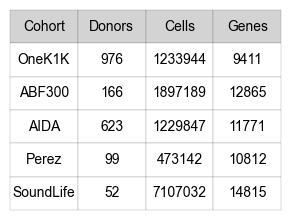

In [5]:
# Create a table plot
df_short = df[df['Cohort'] != 'Zhang']
fig, ax = plt.subplots(figsize=(3.5, .5))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=df_short.values, colLabels=df_short.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

for i in range(len(df_short.columns)):
    table[(0, i)].set_facecolor('#D3D3D3')
for key, cell in table.get_celld().items():
    cell.set_linewidth(0.1)
file_name = f'{PLOTS_DIR}/datasets_summary_table.png'
print(f"Saving table to {file_name}")
plt.savefig(file_name, dpi=300, bbox_inches='tight', transparent=True)

In [ ]:
df['Cells'].sum(), df['Donors'].sum()

(18023161, 1960)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Saving to /vol/projects/jnourisa//output//plots//datasets_summary_Cells.png
Saving to /vol/projects/jnourisa//output//plots//datasets_summary_Donors.png


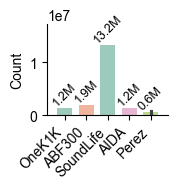

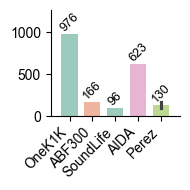

In [ ]:
from hiara.src.config import palette_datasets

# Convert DataFrame to long format for easier plotting
df_long = df.melt(id_vars=["Cohort"], var_name="Metadata", value_name="Count")

cols = ['Cells', 'Donors']

for i, metadata in enumerate(cols):
    fig, ax = plt.subplots(1,1, figsize=(2, 2), sharex=False)
    # Create bar plot
    sns.barplot(data=df, x='Cohort', y=metadata, alpha=.7, ax=ax, hue='Cohort', width=.7, palette=palette_datasets_pretty, legend=False)
    # Annotate bars with values (rotated 45 degrees)
    for p in ax.patches:
        value = int(p.get_height())
        if value > 100000:
            value = f'{value/1e6:.1f}M'
        ax.text(p.get_x() + p.get_width() / 2,  # X position
                p.get_height(),  # Y position (top of bar)
                f'{value}',  # Text label
                ha='center', va='bottom', fontsize=9, rotation=45)  # Rotate 45 degrees

    # Formatting
    # ax.set_title(metadata, pad=20)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.margins(x=0.1, y=0.3)
    
    if i == 0:
        ax.set_ylabel("Count")
    else:
        ax.set_ylabel("")
    
    ax.set_xlabel("")
    ax.legend().remove()
    plt.tight_layout()

    plt.xticks(rotation=45)
    file_name = f'{PLOTS_DIR}/datasets_summary_{metadata}.png'
    print(f'Saving to {file_name}')
    plt.savefig(file_name, bbox_inches='tight', dpi=200, transparent=True)

# plt.show()

In [43]:
# - overall gender coverage
datasets = AGING_COHORTS + ['zhang']
gender_samples = {}
combined_df = []

for dataset in datasets:
    adata = retrieve_adata(dataset)
    adata.obs['donor_age'] = adata.obs['donor_id'].astype(str) + '_' + adata.obs['age'].astype(str)
    df = adata.obs.copy()
    df['sex'] = df['sex'].apply(lambda name: {'F': 'Female', 'M': 'Male'}.get(name, name))
    df = df.drop_duplicates(subset=['donor_age'])
    df['dataset'] = dataset
    combined_df.append(df)

df = pd.concat(combined_df)

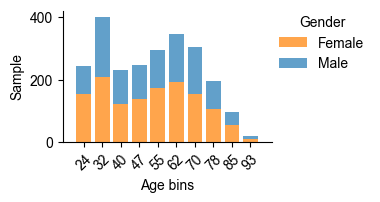

In [44]:
df['sex'] = df['sex'].apply(lambda name: {'F':'Female', 'M':'Male'}.get(name, name))
df = df.drop_duplicates(subset=['donor_age'])
df = df[df['age']>20]
# Count occurrences of each sex within each age group
df_count = df.groupby(['age', 'sex'])['donor_age'].nunique().reset_index(name='count')
# Pivot data for stacking
df_pivot = df_count.pivot(index='age', columns='sex', values='count').fillna(0)
# Plot stacked bar chart
df_pivot['binned'] = pd.cut(df_pivot.index, bins=10)  
df_binned = df_pivot.groupby('binned').sum() 
fig, ax = plt.subplots(figsize=(2.7, 1.7))
df_binned.plot(kind='bar', stacked=True, ax=ax, color=palette_genders, alpha=0.7, width=.8)


ax.set_xlabel("Age bins")
ax.set_ylabel("Sample")  
bin_midpoints = [int(interval.mid) for interval in df_binned.index.categories]
ax.set_xticklabels(bin_midpoints)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min - .5, x_max + .5) 
ax.legend(loc=[1.01, .5], frameon=False, title='Gender')
plt.savefig(f'{PLOTS_DIR}/datasets_age_distribution.png', bbox_inches='tight', dpi=300, transparent=True)


save to /Users/jno24/Documents/projs/ongoing/hiara/base_folder/output//plots//sex_distribution.png


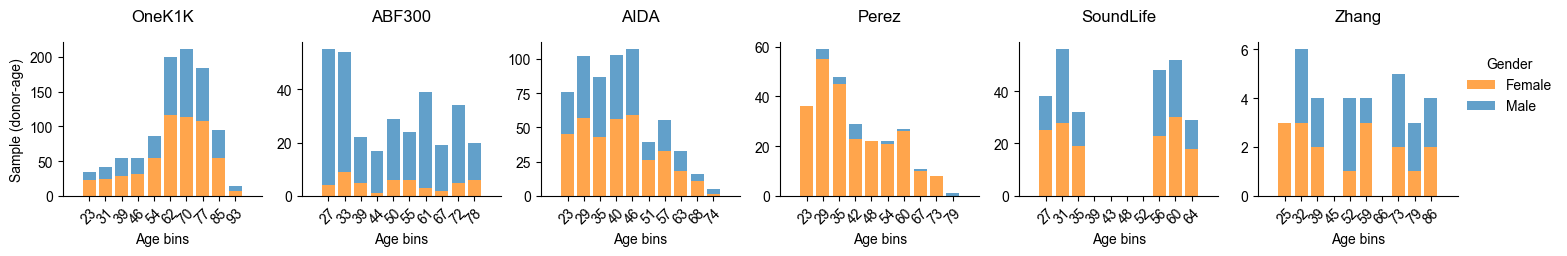

In [45]:
gender_samples = {}
def gender_distribution_plot(datasets):
    fig, axes = plt.subplots(1, len(datasets), figsize=(3*len(datasets), 2), sharey=False)
    for i, dataset in enumerate(datasets):
        adata = retrieve_adata(dataset)
        adata.obs['donor_age'] = adata.obs['donor_id'].astype(str) + '_' + adata.obs['age'].astype(str)
        
        df = adata.obs.copy()
        df['sex'] = df['sex'].apply(lambda name: {'F':'Female', 'M':'Male'}.get(name, name))
        df = df.drop_duplicates(subset=['donor_age'])

        # Count occurrences of each sex within each age group
        df_count = df.groupby(['age', 'sex'])['donor_age'].nunique().reset_index(name='count')
        gender_samples[dataset] = {sex: df_count[df_count['sex']==sex]['count'].sum() for sex in ['Male', 'Female']}

        # Pivot data for stacking
        df_pivot = df_count.pivot(index='age', columns='sex', values='count').fillna(0)

        # Plot stacked bar chart
        df_pivot['binned'] = pd.cut(df_pivot.index, bins=10)  
        df_binned = df_pivot.groupby('binned').sum() 
        df_binned.plot(kind='bar', stacked=True, ax=axes[i], color=palette_genders, alpha=0.7, width=.8)


        axes[i].set_xlabel("Age bins")
        axes[i].set_ylabel("Sample (donor-age)" if i == 0 else "")  
        axes[i].set_title(surrogate_names[dataset], pad=15)
        bin_midpoints = [int(interval.mid) for interval in df_binned.index.categories]
        axes[i].set_xticklabels(bin_midpoints)

        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
        x_min, x_max = axes[i].get_xlim()
        axes[i].set_xlim(x_min - 1, x_max + 1) 
        
        axes[i].get_legend().remove()
    axes[i].legend(loc=(1.02, .5), frameon=False, title='Gender')
    file_name = f'{PLOTS_DIR}/sex_distribution.png'
    print('save to' , file_name)
    plt.savefig(file_name, dpi=200, bbox_inches='tight', transparent=True)
    plt.show()
gender_distribution_plot(datasets)

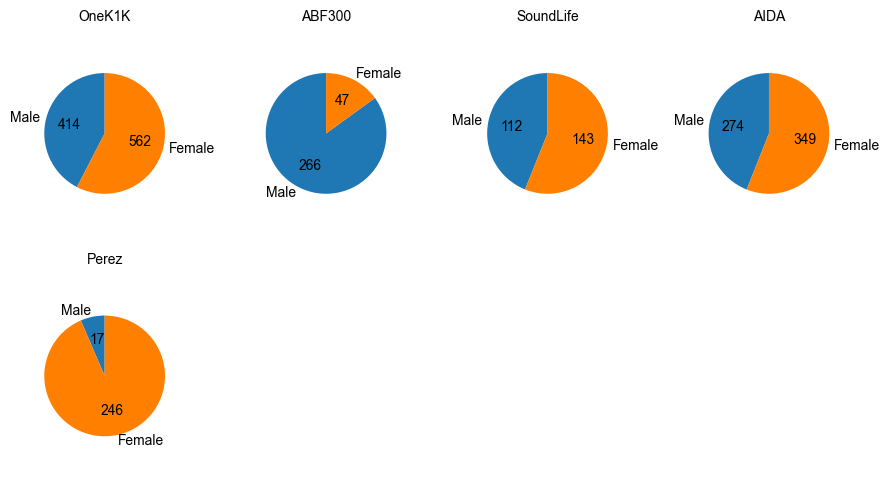

In [ ]:
# Plotting pie charts
fig, axes = plt.subplots(2, 4, figsize=(9, 5))
axes = axes.flatten()

for i, (dataset, counts) in enumerate(gender_samples.items()):
    labels = list(counts.keys())
    sizes = list(counts.values())
    # axes[i].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=palette_genders.values())
    axes[i].pie(sizes, labels=labels, autopct=lambda p: f'{int(round(p * sum(sizes) / 100))}', startangle=90, colors=palette_genders.values())
    
    axes[i].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    axes[i].set_title(surrogate_names[dataset], fontsize=10, weight='bold')

# Hide any unused subplots
for j in range(len(gender_samples), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Ethnicity

In [ ]:
# Collect data from all datasets once
dataset_race_data = []
all_races = set()

for dataset in AGING_COHORTS:
    adata = retrieve_adata(dataset)
    if 'race' not in adata.obs.columns:
        adata.obs['race'] = 'European'
    
    df = (
        adata.obs
        .groupby("race")["donor_id"]
        .nunique()
        .reset_index(name="count")
    )
    
    # Filter races that have at least 2% of the population
    total_donors = df['count'].sum()
    df['percentage'] = (df['count'] / total_donors) * 100
    df = df[df['percentage'] >= 2.0]
    df = df.drop(columns=['percentage'])
    
    if len(df) > 0:  # Only add if there are races meeting the threshold
        dataset_race_data.append((dataset, df))
        all_races.update(df['race'])

Saving to /vol/projects/jnourisa//output//plots//race_composition.png


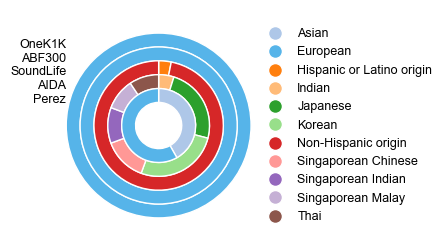

In [ ]:

# Create figure with nested rings
fig, ax = plt.subplots(figsize=(4, 3))

# Map all unique races to distinct colors
all_races = sorted(all_races)
# Use a color palette with enough distinct colors
race_colors = {'European': colors_blind[1]}

color_palette = sns.color_palette("tab20", n_colors=len(all_races))
for race in all_races:
    if race in race_colors.keys():
        continue
    race_colors[race] = color_palette[len(race_colors)]


outer_radius = 1.0
ring_width = 0.15
dataset_labels = []

for i, (dataset, df) in enumerate(dataset_race_data):
    # Ensure colors match races correctly by sorting df by race to match color mapping
    df = df.sort_values('race')
    colors = [race_colors[r] for r in df["race"]]
    
    wedges, texts = ax.pie(
        df["count"],
        radius=outer_radius - i * ring_width,
        colors=colors,
        startangle=90,
        counterclock=False,
        wedgeprops=dict(width=ring_width, edgecolor="white", linewidth=1),
    )
    dataset_labels.append((surrogate_names[dataset], outer_radius - i * ring_width - ring_width/2))
ax.set(aspect="equal")
for dataset_name, radius in dataset_labels:
    ax.text(-1, radius - 0.05, dataset_name, 
            ha='right', va='center', fontsize=9, weight='bold')
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=race_colors[race], markersize=10)
    for race in all_races
]
ax.legend(
    handles,
    all_races,
    # title="Ethnici",
    loc="center left",
    bbox_to_anchor=(.9, 0.5),
    frameon=False,
    fontsize=9,
    labelspacing=0.5
)
# plt.tight_layout()
file_name = f'{PLOTS_DIR}/race_composition.png'
print(f'Saving to {file_name}')
plt.savefig(file_name, bbox_inches='tight', dpi=200, transparent=True)

## Disease

  condition  count
0   healthy     99
1       SLE    162
Saving to /vol/projects/jnourisa//output//plots//disease_composition_perez_sle.png


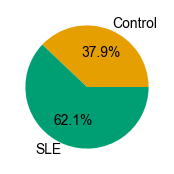

In [ ]:
dataset = 'perez_sle'
adata = retrieve_adata(dataset)
disease_info = adata.obs.groupby('condition')['donor_id'].nunique().reset_index(name='count')
print(disease_info)
fig, ax = plt.subplots(1, 1, figsize=(2, 2))
disease_info['condition'] = disease_info['condition'].replace({'healthy': 'Control'})
colors = {'Control': colors_blind[0], 'SLE': colors_blind[2]}
bb = ax.pie(disease_info['count'], labels=disease_info['condition'], autopct='%1.1f%%', colors=[colors[c] for c in disease_info['condition']], )
# plt.title(surrogate_names[dataset], pad=10)
file_name = f'{PLOTS_DIR}/disease_composition_{dataset}.png'
print(f'Saving to {file_name}')
plt.savefig(file_name, bbox_inches='tight', dpi=200, transparent=True)

Text(0.5, 1.0, 'C6: Covid')

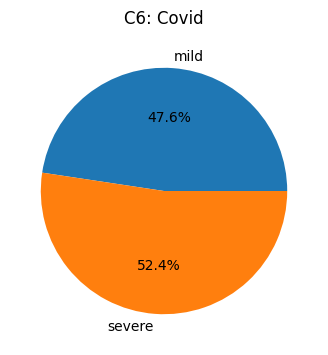

In [ ]:
dataset = 'Covid_50MHH'
adata = retrieve_adata(dataset)

race_info = adata.obs.groupby('Max_WHO_Group')['donor_id'].nunique().reset_index(name='count')
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
bb = ax.pie(race_info['count'], labels=race_info['Max_WHO_Group'], autopct='%1.1f%%')
plt.title(surrogate_names[dataset], pad=10)

In [ ]:
adata.obs.groupby(['cell_type', 'Max_WHO_Group']).size()

cell_type  Max_WHO_Group
B          mild             20
           severe           22
CD4T       mild             20
           severe           22
CD8T       mild             20
           severe           22
MONO       mild             20
           severe           22
NK         mild             20
           severe           22
dtype: int64

# GRNs

## Compare individual nets


In [15]:
from hiara import DISCOVERY_COHORTS
if True:
    net_store = []
    for cell_type in MAJOR_CTS:
        for dataset in DISCOVERY_COHORTS:
            net = retrieve_net(dataset, cell_type)
            net['edge'] = net['source'] + '_' + net['target']
            net['cell_type'] = cell_type
            net['dataset'] = dataset
            print(f'net: {cell_type} {dataset} ', net.shape)
            net_store.append(net)
    nets_all = pd.concat(net_store)

net: CD4T onek1k  (100000, 6)
net: CD4T abf300  (100000, 6)
net: CD4T aida  (100000, 6)
net: CD4T perez_sle  (100000, 6)
net: CD8T onek1k  (100000, 6)
net: CD8T abf300  (100000, 6)
net: CD8T aida  (100000, 6)
net: CD8T perez_sle  (100000, 6)
net: NK onek1k  (100000, 6)
net: NK abf300  (100000, 6)
net: NK aida  (100000, 6)
net: NK perez_sle  (100000, 6)
net: B onek1k  (100000, 6)
net: B abf300  (100000, 6)
net: B aida  (100000, 6)
net: B perez_sle  (100000, 6)
net: MONO onek1k  (100000, 6)
net: MONO abf300  (100000, 6)
net: MONO aida  (100000, 6)
net: MONO perez_sle  (100000, 6)


['ABF300', 'AIDA', 'OneK1K', 'Perez']
Saving to /Users/jno24/Documents/projs/ongoing/hiara/base_folder/output//plots//grn_edge_overlap_CD4T.png
['ABF300', 'AIDA', 'OneK1K', 'Perez']
Saving to /Users/jno24/Documents/projs/ongoing/hiara/base_folder/output//plots//grn_edge_overlap_CD8T.png
['ABF300', 'AIDA', 'OneK1K', 'Perez']
Saving to /Users/jno24/Documents/projs/ongoing/hiara/base_folder/output//plots//grn_edge_overlap_NK.png
['ABF300', 'AIDA', 'OneK1K', 'Perez']
Saving to /Users/jno24/Documents/projs/ongoing/hiara/base_folder/output//plots//grn_edge_overlap_B.png
['ABF300', 'AIDA', 'OneK1K', 'Perez']
Saving to /Users/jno24/Documents/projs/ongoing/hiara/base_folder/output//plots//grn_edge_overlap_MONO.png


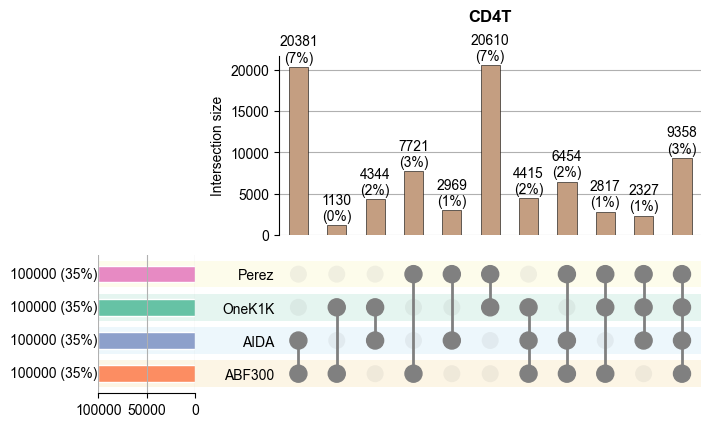

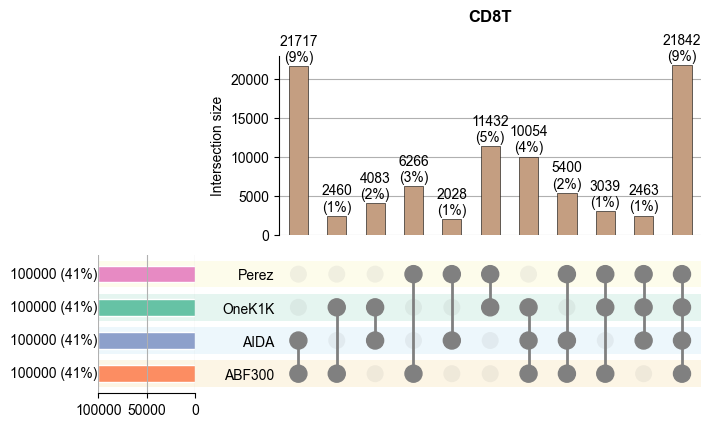

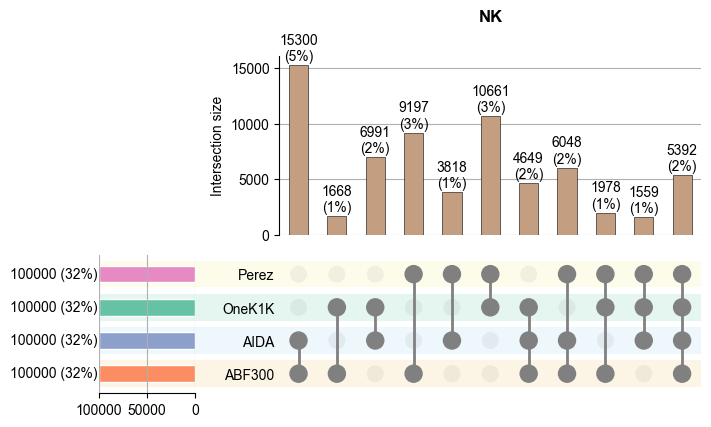

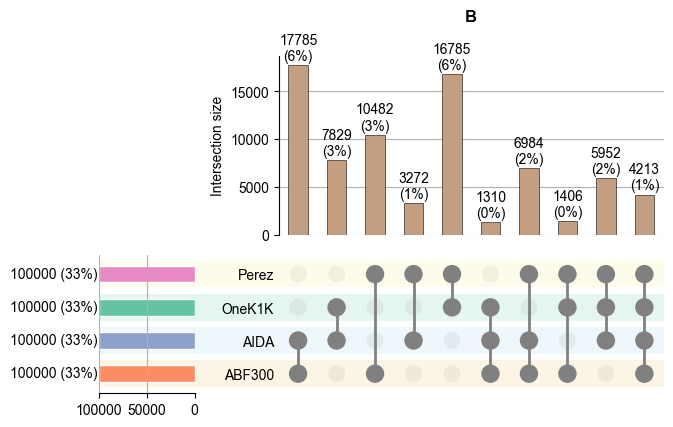

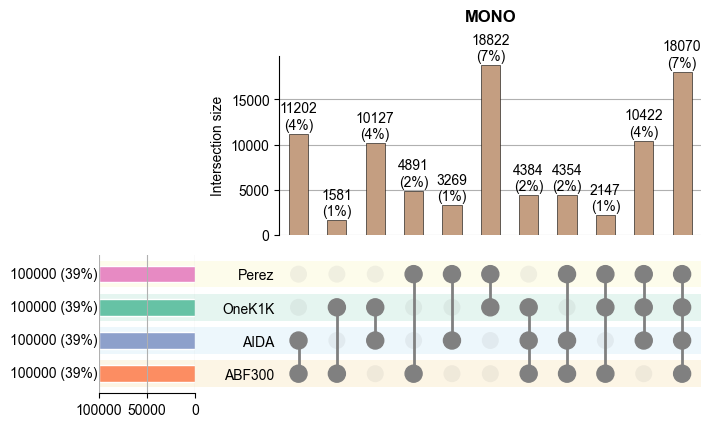

In [17]:
if True:
    to_show = 'edge'
    for cell_type in MAJOR_CTS:
        if to_show=='source':
            min_subset_size=10
            min_degree=1
        if to_show=='target':
            min_subset_size=10
            min_degree=1
        if to_show=='edge':
            min_subset_size=1000
            min_degree=2

        nets = nets_all[nets_all['cell_type']==cell_type]
        df_dict = nets.groupby(['dataset'])[to_show].apply(list).to_dict()

        interaction_df = create_interaction_df(df_dict)
        interaction_df.columns = interaction_df.columns.map(surrogate_names)
        aa = plot_interactions(interaction_df, min_degree=min_degree, min_subset_size=min_subset_size, color_map=palette_datasets_pretty)
        plt.title(cell_type, y=1.15, weight='bold')

        file_name = f'{PLOTS_DIR}/grn_{to_show}_overlap_{cell_type}.png'
        print(f'Saving to {file_name}')
        plt.savefig(file_name, dpi=300, bbox_inches='tight', transparent=True)

## Consensus net

In [18]:
if True:
    net_store = []
    for cell_type in MAJOR_CTS:
        net = retrieve_net_consensus(cell_type=cell_type)
        net['edge'] = net['source'] + '_' + net['target']
        net['cell_type'] = cell_type
        print(f'net: {cell_type} {dataset} ', net.shape)
        net_store.append(net)
    nets_all = pd.concat(net_store)

net: CD4T perez_sle  (79868, 5)
net: CD8T perez_sle  (89411, 5)
net: NK perez_sle  (64955, 5)
net: B perez_sle  (75247, 5)
net: MONO perez_sle  (87821, 5)


['CD8T', 'MONO', 'CD4T', 'B', 'NK']
Saving to /Users/jno24/Documents/projs/ongoing/hiara/base_folder/output//plots//consensus_grn_edge_overlap.png


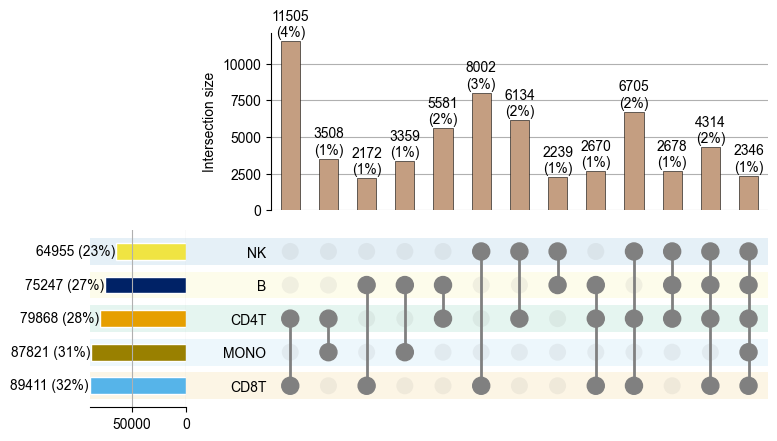

In [30]:
if True:
    to_show = 'edge'
    
    if to_show=='source':
        min_subset_size=10
        min_degree=1
    if to_show=='target':
        min_subset_size=10
        min_degree=1
    if to_show=='edge':
        min_subset_size=2000
        min_degree=2

    df_dict = nets_all.groupby(['cell_type'])[to_show].apply(list).to_dict()
    interaction_df.columns = interaction_df.columns.map(lambda name: surrogate_names.get(name, name))
    aa = plot_interactions(interaction_df, min_degree=min_degree, min_subset_size=min_subset_size, color_map=palette_major_cts)

    file_name = f'{PLOTS_DIR}/consensus_grn_{to_show}_overlap.png'
    print(f'Saving to {file_name}')
    plt.savefig(file_name, dpi=300, bbox_inches='tight', transparent=True)

# CD8T aging TFs mark a naive -> effector shift
Significant aging TFs in CD8T (`tfa_major_b`) are cross-checked against literature master regulators and marker genes of naive vs. effector CD8 T cells, to test whether aging in CD8T reads out as a naive -> effector differentiation shift rather than a distinct aging program.

In [ ]:
cell_type = 'CD8T'
stats = retrieve_stats(analysis_name='tfa_major_b', cell_type=cell_type)
stats_sig = stats[stats['is_significant']].drop_duplicates(subset='gene')[['gene', 'slope', 'meta_p_adj', 'trend']].sort_values('meta_p_adj')
print(f'{len(stats_sig)} significant aging TFs in {cell_type}')

# Literature master regulators of naive/stemness vs effector CD8 T cell differentiation
naive_tfs = ['TCF7', 'LEF1', 'FOXO1', 'BACH2', 'KLF2', 'ID3', 'BCL11B', 'MYB']
effector_tfs = ['TBX21', 'PRDM1', 'ID2', 'ZEB2', 'RUNX3', 'EOMES', 'BATF', 'IRF4', 'STAT4', 'ZEB1']

tf_check = stats.drop_duplicates(subset='gene').set_index('gene').reindex(naive_tfs + effector_tfs)[['slope', 'meta_p_adj', 'trend', 'is_significant']]
tf_check['expected_role'] = ['naive/stemness'] * len(naive_tfs) + ['effector'] * len(effector_tfs)

file_name = f'{FEATURES_DIR}/naive_effector_master_tfs_aging_{cell_type}.csv'
print(f'Saving to {file_name}')
tf_check.to_csv(file_name)
tf_check

All 6/6 naive TFs (TCF7, LEF1, FOXO1, BACH2, MYB, BCL11B) significantly **decrease** with age, and 8/9 effector TFs (EOMES, PRDM1, BATF, RUNX3, TBX21, ZEB2, STAT4, IRF4) significantly **increase** with age -- the only exception is ZEB1, whose role is less canonical/consistent in CD8T than ZEB2. KLF2 and ID2/ID3 are not significant. This matches the naive -> effector direction, not the reverse.

In [ ]:
# Second, independent line of evidence: canonical surface/cytotoxic marker GENE EXPRESSION
# (not TF activity) for naive vs. effector CD8T, from the naive/effector_memory marker sets
# used for sub cell type annotation (see hiara.src.feature_association.trajectory_analysis.annotate)
ge_stats = retrieve_stats(analysis_name='ge_major_b', cell_type=cell_type)
ge_stats = ge_stats.drop_duplicates(subset='gene').set_index('gene')

naive_markers = ['CCR7', 'LEF1', 'SELL', 'TCF7', 'IL7R', 'CD27']
effector_markers = ['CCL5', 'GZMH', 'GZMB', 'PRF1', 'KLRD1', 'NKG7', 'GNLY']

marker_check = ge_stats.reindex(naive_markers + effector_markers)[['slope', 'meta_p_adj', 'trend', 'is_significant']]
marker_check['expected_role'] = ['naive'] * len(naive_markers) + ['effector'] * len(effector_markers)

file_name = f'{FEATURES_DIR}/naive_effector_marker_genes_aging_{cell_type}.csv'
print(f'Saving to {file_name}')
marker_check.to_csv(file_name)
marker_check

5/6 naive markers (CCR7, LEF1, SELL, TCF7, IL7R) significantly **decrease** with age (CD27 is 'Inconsistent' across cohorts), and 6/7 effector markers (CCL5, NKG7, GZMH, GZMB, PRF1, GNLY) significantly **increase** with age (KLRD1 trends the same way but misses genome-wide significance). Combined with the TF-activity result above, both regulators and their downstream marker genes point the same direction: CD8T aging in this cohort looks like accumulation of an effector-differentiated phenotype at the expense of the naive/stem-like state, not a cell-type-intrinsic aging signature independent of differentiation state.